In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

sns.set_theme(style="whitegrid")

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Розмір train:", train_df.shape)
print("Розмір test:", test_df.shape)

Розмір train: (3584, 3)
Розмір test: (3585, 2)



Пропущені значення в train:
image_id    0
type        0
count       0
dtype: int64

Пропущені значення в test:
image_id    0
type        0
dtype: int64


/tmp/ipykernel_56093/2063367633.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='type', ax=axes[0], palette='viridis', order=class_order)
/tmp/ipykernel_56093/2063367633.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='type', ax=axes[1], palette='viridis', order=class_order)


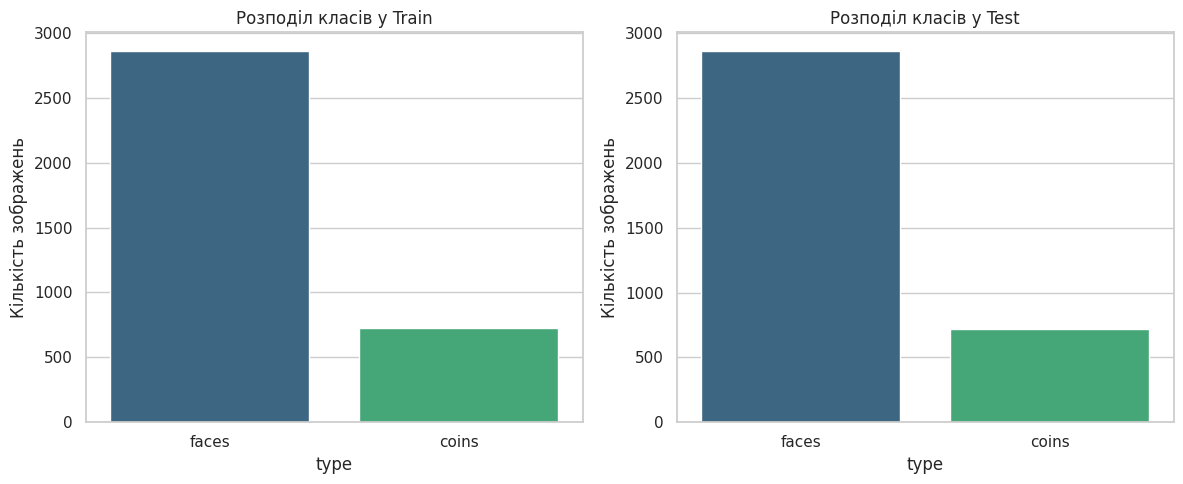

In [13]:
print("\nПропущені значення в train:")
print(train_df.isnull().sum())
print("\nПропущені значення в test:")
print(test_df.isnull().sum())

class_order = ['faces', 'coins']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=train_df, x='type', ax=axes[0], palette='viridis', order=class_order)
axes[0].set_title('Розподіл класів у Train')
axes[0].set_ylabel('Кількість зображень')

sns.countplot(data=test_df, x='type', ax=axes[1], palette='viridis', order=class_order)
axes[1].set_title('Розподіл класів у Test')
axes[1].set_ylabel('Кількість зображень')

plt.tight_layout()
plt.show()

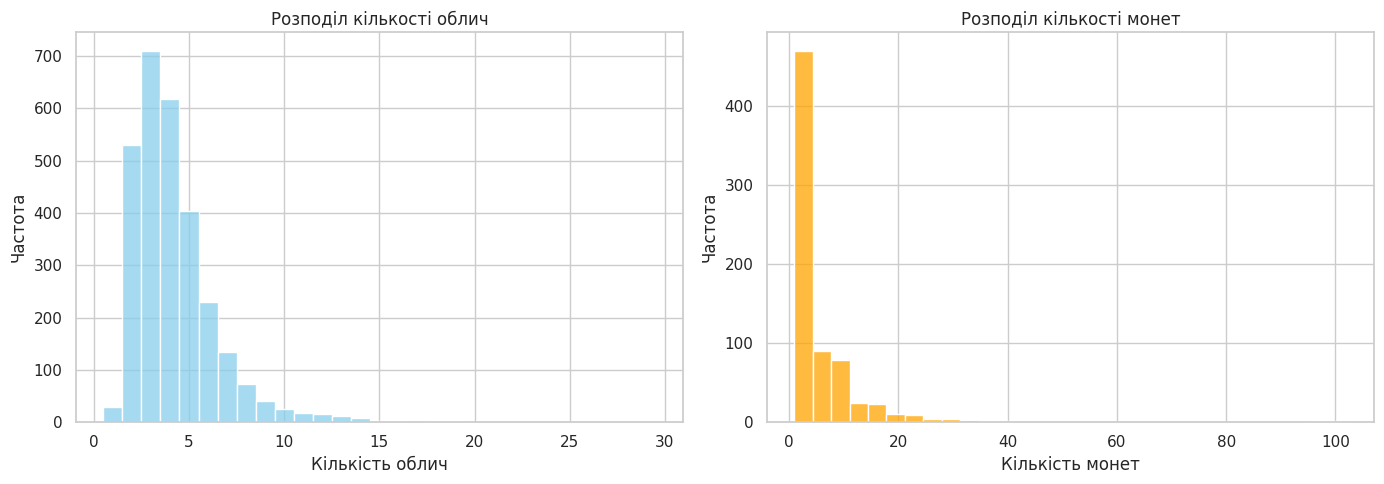


Статистика цільової змінної по класах:


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
coins,723.0,5.255878,7.834300,1.0,1.0,2.0,6.0,102.0
faces,2861.0,4.241524,2.338497,1.0,3.0,4.0,5.0,29.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df[train_df['type'] == 'faces'], x='count', 
             bins=15, ax=axes[0], color='skyblue', discrete=True)
axes[0].set_title('Розподіл кількості облич')
axes[0].set_xlabel('Кількість облич')
axes[0].set_ylabel('Частота')

sns.histplot(data=train_df[train_df['type'] == 'coins'], x='count', 
             bins=30, ax=axes[1], color='orange')
axes[1].set_title('Розподіл кількості монет')
axes[1].set_xlabel('Кількість монет')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("\nСтатистика цільової змінної по класах:")
display(train_df.groupby('type')['count'].describe())

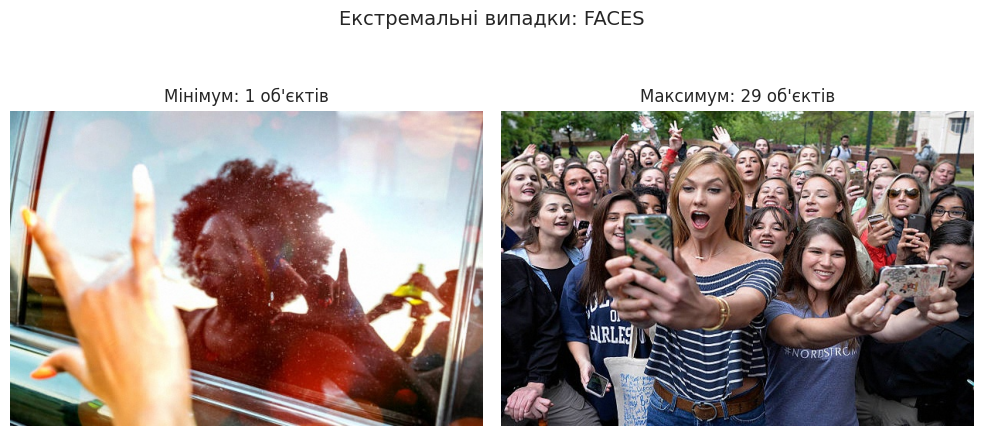

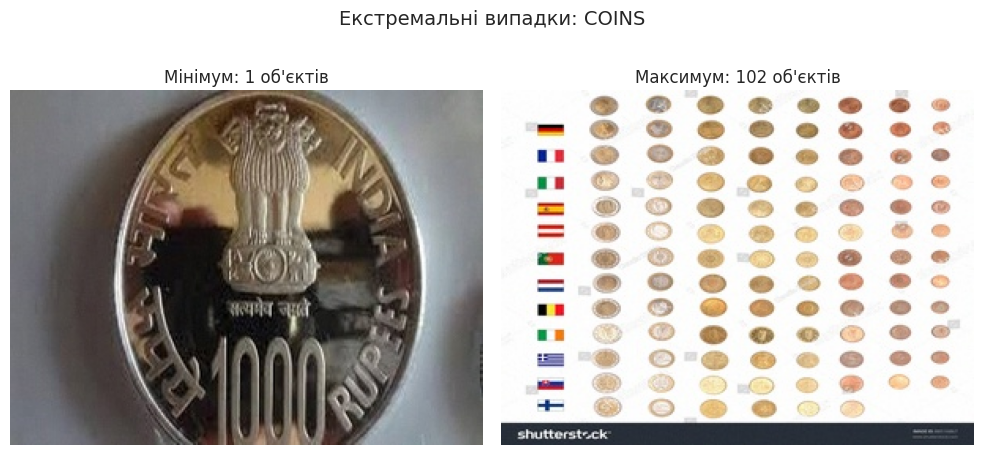

In [20]:
import matplotlib.image as mpimg
import os
import matplotlib.pyplot as plt

TRAIN_IMAGES_DIR = 'train/' 
IMAGE_EXT = '.jpg' 

def plot_extreme_cases_minimal(df, obj_type, images_dir):
    subset = df[df['type'] == obj_type]
    
    min_row = subset.loc[subset['count'].idxmin()]
    max_row = subset.loc[subset['count'].idxmax()]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f'Екстремальні випадки: {obj_type.upper()}', fontsize=14)
    
    img_path_min = os.path.join(images_dir, str(min_row['image_id']) + IMAGE_EXT)
    try:
        img_min = mpimg.imread(img_path_min)
        axes[0].imshow(img_min)
        axes[0].set_title(f"Мінімум: {min_row['count']} об'єктів")
    except FileNotFoundError:
        axes[0].set_title(f"Файл не знайдено:\n{min_row['image_id']}")
    axes[0].axis('off')
        
    img_path_max = os.path.join(images_dir, str(max_row['image_id']) + IMAGE_EXT)
    try:
        img_max = mpimg.imread(img_path_max)
        axes[1].imshow(img_max)
        axes[1].set_title(f"Максимум: {max_row['count']} об'єктів")
    except FileNotFoundError:
        axes[1].set_title(f"Файл не знайдено:\n{max_row['image_id']}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

plot_extreme_cases_minimal(train_df, 'faces', TRAIN_IMAGES_DIR)
plot_extreme_cases_minimal(train_df, 'coins', TRAIN_IMAGES_DIR)

In [25]:
# Random Split

from sklearn.model_selection import train_test_split
import pandas as pd

def analyze_split(train_df, val_df, split_name="Стратегія"):
    
    results = []
    for name, df in [("Train", train_df), ("Validation", val_df)]:
        total_len = len(df)
        
        for obj_type in ['faces', 'coins']:
            subset = df[df['type'] == obj_type]
            
            class_ratio = (len(subset) / total_len) * 100
            
            results.append({
                "Вибірка": name,
                "Клас": obj_type,
                "Частка (%)": f"{class_ratio:.1f}%",
                "Мінімум": subset['count'].min(),
                "Максимум": subset['count'].max(),
                "Середнє": round(subset['count'].mean(), 2)
            })
            
    return pd.DataFrame(results)

train_random, val_random = train_test_split(train_df, test_size=0.2, random_state=42)

comparison_random = analyze_split(train_random, val_random)
display(comparison_random)

,Вибірка,Клас,Частка (%),Мінімум,Максимум,Середнє
0,Train,faces,80.0%,1,28,4.22
1,Train,coins,20.0%,1,96,4.98
2,Validation,faces,79.1%,1,29,4.32
3,Validation,coins,20.9%,1,102,6.30


In [26]:
# Stratified Split

from sklearn.model_selection import train_test_split
import pandas as pd

def analyze_split(train_df, val_df):
    results = []
    for name, df in [("Train", train_df), ("Validation", val_df)]:
        total_len = len(df)
        for obj_type in ['faces', 'coins']:
            subset = df[df['type'] == obj_type]
            class_ratio = (len(subset) / total_len) * 100
            results.append({
                "Вибірка": name,
                "Клас": obj_type,
                "Частка (%)": f"{class_ratio:.1f}%",
                "Мінімум": subset['count'].min(),
                "Максимум": subset['count'].max(),
                "Середнє": round(subset['count'].mean(), 2)
            })
    return pd.DataFrame(results)

train_strat, val_strat = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['type'])

comparison_strat = analyze_split(train_strat, val_strat)
display(comparison_strat)

,Вибірка,Клас,Частка (%),Мінімум,Максимум,Середнє
0,Train,faces,79.8%,1,29,4.23
1,Train,coins,20.2%,1,102,5.37
2,Validation,faces,79.8%,1,24,4.29
3,Validation,coins,20.2%,1,96,4.79


In [27]:
# Group-Based Split

import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

train_df['group_id'] = np.repeat(np.arange(len(train_df) // 10 + 1), 10)[:len(train_df)]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss.split(train_df, train_df['type'], groups=train_df['group_id']))

train_group = train_df.iloc[train_idx]
val_group = train_df.iloc[val_idx]

comparison_group = analyze_split(train_group, val_group)
display(comparison_group)

,Вибірка,Клас,Частка (%),Мінімум,Максимум,Середнє
0,Train,faces,80.3%,1,29,4.24
1,Train,coins,19.7%,1,96,5.22
2,Validation,faces,77.8%,1,18,4.24
3,Validation,coins,22.2%,1,102,5.39


In [28]:
# K-Fold Cross-Validation

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_idx_kf, val_idx_kf = next(kf.split(train_df))

train_kf = train_df.iloc[train_idx_kf]
val_kf = train_df.iloc[val_idx_kf]

comparison_kf = analyze_split(train_kf, val_kf)
display(comparison_kf)

,Вибірка,Клас,Частка (%),Мінімум,Максимум,Середнє
0,Train,faces,80.0%,1,28,4.22
1,Train,coins,20.0%,1,96,4.98
2,Validation,faces,79.1%,1,29,4.32
3,Validation,coins,20.9%,1,102,6.30


In [30]:
# Adversarial Validation

from sklearn.ensemble import RandomForestClassifier

adv_train = train_df[['type']].copy()
adv_train['is_test'] = 0

adv_test = test_df[['type']].copy()
adv_test['is_test'] = 1

adv_data = pd.concat([adv_train, adv_test])

adv_data['type_encoded'] = adv_data['type'].map({'faces': 0, 'coins': 1})

X_adv = adv_data[['type_encoded']]
y_adv = adv_data['is_test']

clf = RandomForestClassifier(random_state=42)
clf.fit(X_adv, y_adv)

train_probs = clf.predict_proba(X_adv[adv_data['is_test'] == 0])[:, 1]

train_df_adv = train_df.copy()
train_df_adv['test_prob'] = train_probs
train_df_adv = train_df_adv.sort_values(by='test_prob', ascending=False)

val_size = int(len(train_df_adv) * 0.2)
val_adv = train_df_adv.iloc[:val_size]
train_adv = train_df_adv.iloc[val_size:]

comparison_adv = analyze_split(train_adv, val_adv)
display(comparison_adv)

,Вибірка,Клас,Частка (%),Мінімум,Максимум,Середнє
0,Train,faces,74.8%,1.0,29.0,4.26
1,Train,coins,25.2%,1.0,102.0,5.26
2,Validation,faces,100.0%,1.0,19.0,4.18
3,Validation,coins,0.0%,NaN,NaN,NaN


In [39]:
# Haar Cascades і Hough Circle Transform

import cv2
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from tqdm import tqdm

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def calculate_metrics_cv(y_true, y_pred, subset_name):
    y_pred_rounded = np.clip(np.round(y_pred), 0, None)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    exact_match = accuracy_score(y_true, y_pred_rounded)
    
    return {
        'Клас': subset_name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Exact Match': round(exact_match, 4)
    }

def count_faces_haar(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
    
    return len(faces) if len(faces) > 0 else 1

def count_coins_hough(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 5) 
    
    circles = cv2.HoughCircles(
        blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1.2, 
        minDist=20,  
        param1=50,  
        param2=30,   
        minRadius=10, 
        maxRadius=150
    )
    
    if circles is not None:
        return circles.shape[1]
    return 1

predictions = []
y_true = []
types = []

for _, row in tqdm(val_strat.iterrows(), total=len(val_strat)):
    img_path = os.path.join(TRAIN_IMAGES_DIR, str(row['image_id']) + IMAGE_EXT)
    
    if row['type'] == 'faces':
        pred = count_faces_haar(img_path)
    else:
        pred = count_coins_hough(img_path)
        
    predictions.append(pred)
    y_true.append(row['count'])
    types.append(row['type'])

results_df = pd.DataFrame({'true': y_true, 'pred': predictions, 'type': types})

metrics_list = []

metrics_list.append(calculate_metrics_cv(results_df['true'], results_df['pred'], "Global"))

faces_df = results_df[results_df['type'] == 'faces']
metrics_list.append(calculate_metrics_cv(faces_df['true'], faces_df['pred'], "Faces"))

coins_df = results_df[results_df['type'] == 'coins']
metrics_list.append(calculate_metrics_cv(coins_df['true'], coins_df['pred'], "Coins"))

metrics_summary = pd.DataFrame(metrics_list)
display(metrics_summary)

100%|█████████████████████████████████████████████████████████████████████| 717/717 [00:16<00:00, 44.48it/s]


,Клас,RMSE,MAE,Exact Match
0,Global,42.3162,20.0293,0.1269
1,Faces,3.0281,2.0542,0.1591
2,Coins,93.9060,90.9379,0.0000


In [40]:
# Histogram of Oriented Gradients з SVM і Watershed Algorithm

import cv2
import os
import numpy as np
import pandas as pd
import dlib
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from tqdm import tqdm

hog_face_detector = dlib.get_frontal_face_detector()

def calculate_metrics_cv(y_true, y_pred, subset_name):
    y_pred_rounded = np.clip(np.round(y_pred), 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    exact_match = accuracy_score(y_true, y_pred_rounded)
    return {
        'Клас': subset_name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Exact Match': round(exact_match, 4)
    }

def count_faces_hog(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    faces = hog_face_detector(rgb_img, 1) 
    
    return len(faces) if len(faces) > 0 else 1

def count_coins_watershed(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1 
    markers[unknown == 255] = 0 
    
    markers = cv2.watershed(img, markers)
    
    unique_markers = len(np.unique(markers)) - 2
    
    return unique_markers if unique_markers > 0 else 1

predictions = []
y_true = []
types = []

for _, row in tqdm(val_strat.iterrows(), total=len(val_strat)):
    img_path = os.path.join(TRAIN_IMAGES_DIR, str(row['image_id']) + IMAGE_EXT)
    
    if row['type'] == 'faces':
        pred = count_faces_hog(img_path)
    else:
        pred = count_coins_watershed(img_path)
        
    predictions.append(pred)
    y_true.append(row['count'])
    types.append(row['type'])

results_df_hw = pd.DataFrame({'true': y_true, 'pred': predictions, 'type': types})

metrics_list_hw = []
metrics_list_hw.append(calculate_metrics_cv(results_df_hw['true'], results_df_hw['pred'], "Global"))

faces_df_hw = results_df_hw[results_df_hw['type'] == 'faces']
metrics_list_hw.append(calculate_metrics_cv(faces_df_hw['true'], faces_df_hw['pred'], "Faces"))

coins_df_hw = results_df_hw[results_df_hw['type'] == 'coins']
metrics_list_hw.append(calculate_metrics_cv(coins_df_hw['true'], coins_df_hw['pred'], "Coins"))

metrics_summary_hw = pd.DataFrame(metrics_list_hw)
display(metrics_summary_hw)

100%|█████████████████████████████████████████████████████████████████████| 717/717 [00:48<00:00, 14.88it/s]


,Клас,RMSE,MAE,Exact Match
0,Global,6.1531,2.8815,0.3026
1,Faces,2.7567,1.6766,0.3462
2,Coins,12.5393,7.6345,0.1310


In [41]:
# Local Binary Patterns Cascades і Contour Detection

import cv2
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from tqdm import tqdm

try:
    lbp_face_cascade = cv2.CascadeClassifier('lbpcascade_frontalface.xml')
    if lbp_face_cascade.empty():
        print("Попередження: Не вдалося завантажити lbpcascade_frontalface.xml. Перевірте шлях.")
except Exception as e:
    print(f"Помилка завантаження каскаду: {e}")

def calculate_metrics_cv(y_true, y_pred, subset_name):
    y_pred_rounded = np.clip(np.round(y_pred), 0, None)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    exact_match = accuracy_score(y_true, y_pred_rounded)
    return {
        'Клас': subset_name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Exact Match': round(exact_match, 4)
    }

def count_faces_lbp(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = lbp_face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
    
    return len(faces) if len(faces) > 0 else 1

def count_coins_contours(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    kernel = np.ones((3, 3), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    coin_count = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 100 < area < 50000: 
            coin_count += 1
            
    return coin_count if coin_count > 0 else 1

predictions = []
y_true = []
types = []

for _, row in tqdm(val_strat.iterrows(), total=len(val_strat)):
    img_path = os.path.join(TRAIN_IMAGES_DIR, str(row['image_id']) + IMAGE_EXT)
    
    if row['type'] == 'faces':
        pred = count_faces_lbp(img_path)
    else:
        pred = count_coins_contours(img_path)
        
    predictions.append(pred)
    y_true.append(row['count'])
    types.append(row['type'])

results_df_lc = pd.DataFrame({'true': y_true, 'pred': predictions, 'type': types})

metrics_list_lc = []
metrics_list_lc.append(calculate_metrics_cv(results_df_lc['true'], results_df_lc['pred'], "Global"))

faces_df_lc = results_df_lc[results_df_lc['type'] == 'faces']
metrics_list_lc.append(calculate_metrics_cv(faces_df_lc['true'], faces_df_lc['pred'], "Faces"))

coins_df_lc = results_df_lc[results_df_lc['type'] == 'coins']
metrics_list_lc.append(calculate_metrics_cv(coins_df_lc['true'], coins_df_lc['pred'], "Coins"))

metrics_summary_lc = pd.DataFrame(metrics_list_lc)
display(metrics_summary_lc)


100%|████████████████████████████████████████████████████████████████████| 717/717 [00:05<00:00, 140.37it/s]


,Клас,RMSE,MAE,Exact Match
0,Global,3.9578,2.523,0.1729
1,Faces,3.3865,2.486,0.1084
2,Coins,5.6757,2.669,0.4276


In [42]:
# Classical Computer Vision submission

import cv2
import os
import numpy as np
import pandas as pd
import dlib
from tqdm import tqdm

TEST_IMAGES_DIR = 'test/' 
IMAGE_EXT = '.jpg'

hog_face_detector = dlib.get_frontal_face_detector()

def count_faces_best(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = hog_face_detector(rgb_img, 1) 
    
    return len(faces) if len(faces) > 0 else 1

def count_coins_best(image_path):
    img = cv2.imread(image_path)
    if img is None: return 1
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    kernel = np.ones((3, 3), np.uint8)
    closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    coin_count = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 100 < area < 50000: 
            coin_count += 1
            
    return coin_count if coin_count > 0 else 1

test_df = pd.read_csv('test.csv')

predictions = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_path = os.path.join(TEST_IMAGES_DIR, str(row['image_id']) + IMAGE_EXT)
    
    if row['type'] == 'faces':
        pred = count_faces_best(img_path)
    else:
        pred = count_coins_best(img_path)
        
    predictions.append(pred)

submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'count': predictions
})

submission_df['count'] = submission_df['count'].astype(int)

submission_file = 'submission_classical_cv.csv'
submission_df.to_csv(submission_file, index=False)

print(submission_df.head())

100%|███████████████████████████████████████████████████████████████████| 3585/3585 [03:59<00:00, 14.96it/s]

                                   image_id  count
0  b6e281181c11269eaa1c11256c1582c5effec630      1
1  53189001e2ede913f9c1be729d7cabe0036746d3     12
2  aa8b264fd88180788a8dae046ead5bd6198005e6      1
3  705d7c1e06127ddb5d2905cc6806f0c544bc3387      1
4  459864ffbec10f5f863d52909a3e295b8c644a14      4


In [2]:
import cv2
import os
import numpy as np
import pandas as pd
import dlib
from tqdm import tqdm

TRAIN_IMAGES_DIR = 'train/'
TEST_IMAGES_DIR = 'test/'
IMAGE_EXT = '.jpg'

hog_detector = dlib.get_frontal_face_detector()
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

lbp_cascade = cv2.CascadeClassifier('lbpcascade_frontalface.xml')
if lbp_cascade.empty():
    print("error lbpcascade_frontalface.xml.")

def extract_all_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return {
            'brightness': 0, 'contrast': 0, 
            'faces_haar': 0, 'faces_lbp': 0, 'faces_hog': 0,
            'coins_hough': 0, 'coins_watershed': 0, 
            'coins_contours': 0, 'total_contour_area': 0
        }
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    brightness = np.mean(gray)
    contrast = np.std(gray)
    
    faces_h = haar_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
    count_haar = len(faces_h)
    
    if not lbp_cascade.empty():
        faces_l = lbp_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
        count_lbp = len(faces_l)
    else:
        count_lbp = 0
        
    faces_hog = hog_detector(rgb_img, 1)
    count_hog = len(faces_hog)
 
    blurred_hough = cv2.medianBlur(gray, 5)
    circles = cv2.HoughCircles(blurred_hough, cv2.HOUGH_GRADIENT, dp=1.2, minDist=20, 
                               param1=50, param2=30, minRadius=10, maxRadius=150)
    count_hough = circles.shape[1] if circles is not None else 0
    
    count_watershed = 0
    try:
        _, thresh_ws = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        kernel_ws = np.ones((3,3), np.uint8)
        opening_ws = cv2.morphologyEx(thresh_ws, cv2.MORPH_OPEN, kernel_ws, iterations=2)
        sure_bg = cv2.dilate(opening_ws, kernel_ws, iterations=3)
        dist_transform = cv2.distanceTransform(opening_ws, cv2.DIST_L2, 5)
        _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)
        unknown = cv2.subtract(sure_bg, sure_fg)
        _, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1
        markers[unknown == 255] = 0
        markers = cv2.watershed(img, markers)
        count_watershed = max(0, len(np.unique(markers)) - 2)
    except:
        count_watershed = 0 
        
    blurred_cnt = cv2.GaussianBlur(gray, (9, 9), 0)
    thresh_cnt = cv2.adaptiveThreshold(blurred_cnt, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY_INV, 11, 2)
    kernel_cnt = np.ones((3, 3), np.uint8)
    closing_cnt = cv2.morphologyEx(thresh_cnt, cv2.MORPH_CLOSE, kernel_cnt, iterations=2)
    contours, _ = cv2.findContours(closing_cnt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    count_contours = 0
    total_area = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 100 < area < 50000:
            count_contours += 1
            total_area += area
            
    return {
        'brightness': round(brightness, 2), 
        'contrast': round(contrast, 2), 
        'faces_haar': count_haar, 
        'faces_lbp': count_lbp, 
        'faces_hog': count_hog,
        'coins_hough': count_hough, 
        'coins_watershed': count_watershed, 
        'coins_contours': count_contours, 
        'total_contour_area': round(total_area, 2)
    }

def process_full_dataset(df, images_dir, desc):
    all_features = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        img_path = os.path.join(images_dir, str(row['image_id']) + IMAGE_EXT)
        
        # Вилучаємо фічі
        features = extract_all_features(img_path)
        
        features['image_id'] = row['image_id']
        features['type'] = row['type']
        
        if 'count' in row:
            features['count'] = row['count']
            
        all_features.append(features)
        
    cols_order = ['image_id', 'type'] + [k for k in all_features[0].keys() if k not in ['image_id', 'type', 'count']]
    if 'count' in all_features[0]:
        cols_order.append('count')
        
    return pd.DataFrame(all_features)[cols_order]

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_features_df = process_full_dataset(train_df, TRAIN_IMAGES_DIR, "Train features")
train_features_df.to_csv('train_features.csv', index=False)

test_features_df = process_full_dataset(test_df, TEST_IMAGES_DIR, "Test features")
test_features_df.to_csv('test_features.csv', index=False)

Test features: 100%|██████████████████████████████████████████████████████████| 3585/3585 [23:40<00:00,  2.52it/s]


In [6]:
# Random Forest

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

train_df = pd.read_csv('train_features.csv')
test_df = pd.read_csv('test_features.csv')

best_features = [
    'coins_contours', 
    'coins_watershed', 
    'brightness', 
    'coins_hough', 
    'faces_hog', 
    'total_contour_area', 
    'contrast'
]

X_train_pruned = train_df[best_features]
y_train = train_df['count']

X_test_pruned = test_df[best_features]

rf_model_pruned = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model_pruned.fit(X_train_pruned, y_train)

preds_pruned = rf_model_pruned.predict(X_test_pruned)

preds_rounded_pruned = np.clip(np.round(preds_pruned), 1, None).astype(int)

submission_df_pruned = pd.DataFrame({
    'image_id': test_df['image_id'],
    'count': preds_rounded_pruned
})

submission_name = 'submission_rf.csv'
submission_df_pruned.to_csv(submission_name, index=False)

importances_pruned = rf_model_pruned.feature_importances_
importance_df_pruned = pd.DataFrame({
    'Feature': best_features, 
    'Importance': importances_pruned
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(importance_df_pruned.to_string())

              Feature  Importance
0      coins_contours    0.244482
1     coins_watershed    0.189302
2          brightness    0.131299
3         coins_hough    0.126791
4           faces_hog    0.105534
5            contrast    0.103694
6  total_contour_area    0.098898


In [8]:
# XGBoost

import pandas as pd
import numpy as np
from xgboost import XGBRegressor

train_df = pd.read_csv('train_features.csv')
test_df = pd.read_csv('test_features.csv')

train_df['type_encoded'] = train_df['type'].map({'faces': 0, 'coins': 1})
test_df['type_encoded'] = test_df['type'].map({'faces': 0, 'coins': 1})

y_train = train_df['count']

best_xgb_features = [
    'type_encoded', 
    'coins_contours', 
    'faces_hog', 
    'brightness', 
    'coins_watershed', 
    'faces_haar'
]

X_train_pruned = train_df[best_xgb_features]
X_test_pruned = test_df[best_xgb_features]

xgb_pruned = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_pruned.fit(X_train_pruned, y_train)

preds_pruned = xgb_pruned.predict(X_test_pruned)

preds_rounded_pruned = np.clip(np.round(preds_pruned), 1, None).astype(int)

submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'count': preds_rounded_pruned
})

submission_name = 'submission_xgb.csv'
submission_df.to_csv(submission_name, index=False)

importances_pruned = xgb_pruned.feature_importances_
imp_df_pruned = pd.DataFrame({
    'Feature': best_xgb_features, 
    'Importance': importances_pruned
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(imp_df_pruned.to_string())

           Feature  Importance
0     type_encoded    0.470825
1   coins_contours    0.152115
2        faces_hog    0.151202
3       faces_haar    0.080622
4  coins_watershed    0.075212
5       brightness    0.070024


In [12]:
# Ridge Regression

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train_df = pd.read_csv('train_features.csv')
test_df = pd.read_csv('test_features.csv')

train_df['type_encoded'] = train_df['type'].map({'faces': 0, 'coins': 1})
test_df['type_encoded'] = test_df['type'].map({'faces': 0, 'coins': 1})

y_train = train_df['count']

best_ridge_features = [
    'type_encoded', 
    'faces_hog', 
    'coins_watershed', 
    'coins_contours', 
    'faces_haar', 
    'total_contour_area', 
    'brightness'
]

X_train_pruned = train_df[best_ridge_features]
X_test_pruned = test_df[best_ridge_features]

ridge_pipeline_pruned = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=42))
])

ridge_pipeline_pruned.fit(X_train_pruned, y_train)

preds_pruned = ridge_pipeline_pruned.predict(X_test_pruned)

preds_rounded_pruned = np.clip(np.round(preds_pruned), 1, None).astype(int)

submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'count': preds_rounded_pruned
})

submission_name = 'submission_ridge.csv'
submission_df.to_csv(submission_name, index=False)

ridge_model_pruned = ridge_pipeline_pruned.named_steps['ridge']
abs_coefs_pruned = np.abs(ridge_model_pruned.coef_)
normalized_importances_pruned = abs_coefs_pruned / np.sum(abs_coefs_pruned)

importance_df_pruned = pd.DataFrame({
    'Feature': best_ridge_features, 
    'Importance': normalized_importances_pruned
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(importance_df_pruned.to_string())

              Feature  Importance
0        type_encoded    0.269695
1           faces_hog    0.181949
2     coins_watershed    0.166866
3      coins_contours    0.134814
4  total_contour_area    0.087683
5          faces_haar    0.084872
6          brightness    0.074122


In [16]:
# Lasso Regression

import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

train_df = pd.read_csv('train_features.csv')
test_df = pd.read_csv('test_features.csv')

train_df['type_encoded'] = train_df['type'].map({'faces': 0, 'coins': 1})
test_df['type_encoded'] = test_df['type'].map({'faces': 0, 'coins': 1})

y_train = train_df['count']

best_lasso_features = [
    'type_encoded', 
    'coins_watershed', 
    'faces_hog', 
    'faces_haar', 
    'coins_contours', 
    'brightness'
]

X_train_pruned = train_df[best_lasso_features]
X_test_pruned = test_df[best_lasso_features]

lasso_pipeline_pruned = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1, random_state=42))
])

lasso_pipeline_pruned.fit(X_train_pruned, y_train)

preds_pruned = lasso_pipeline_pruned.predict(X_test_pruned)

preds_rounded_pruned = np.clip(np.round(preds_pruned), 1, None).astype(int)

submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'count': preds_rounded_pruned
})

submission_name = 'submission_lasso.csv'
submission_df.to_csv(submission_name, index=False)

lasso_model_pruned = lasso_pipeline_pruned.named_steps['lasso']
abs_coefs_pruned = np.abs(lasso_model_pruned.coef_)

sum_coefs = np.sum(abs_coefs_pruned)
if sum_coefs > 0:
    normalized_importances_pruned = abs_coefs_pruned / sum_coefs
else:
    normalized_importances_pruned = abs_coefs_pruned

importance_df_pruned = pd.DataFrame({
    'Feature': best_lasso_features, 
    'Importance': normalized_importances_pruned
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(importance_df_pruned.to_string())

           Feature  Importance
0     type_encoded    0.258147
1  coins_watershed    0.240479
2        faces_hog    0.238655
3       faces_haar    0.133085
4       brightness    0.071460
5   coins_contours    0.058174


In [22]:
# Support Vector Regression

import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

train_df = pd.read_csv('train_features.csv')
test_df = pd.read_csv('test_features.csv')

train_df['type_encoded'] = train_df['type'].map({'faces': 0, 'coins': 1})
test_df['type_encoded'] = test_df['type'].map({'faces': 0, 'coins': 1})

y_train = train_df['count']

best_svr_features = [
    'faces_hog', 
    'type_encoded', 
    'coins_contours', 
    'brightness', 
    'total_contour_area', 
    'faces_haar', 
    'faces_lbp'
]

X_train_pruned = train_df[best_svr_features]
X_test_pruned = test_df[best_svr_features]

svr_pipeline_pruned = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

svr_pipeline_pruned.fit(X_train_pruned, y_train)

preds_pruned = svr_pipeline_pruned.predict(X_test_pruned)

preds_rounded_pruned = np.clip(np.round(preds_pruned), 1, None).astype(int)

submission_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'count': preds_rounded_pruned
})

submission_name = 'submission_svr.csv'
submission_df.to_csv(submission_name, index=False)

perm_importance_pruned = permutation_importance(
    svr_pipeline_pruned, X_train_pruned, y_train, n_repeats=5, random_state=42
)

importances_svr_pruned = perm_importance_pruned.importances_mean

importances_svr_pruned = np.maximum(importances_svr_pruned, 0)

sum_importances = np.sum(importances_svr_pruned)
if sum_importances > 0:
    normalized_importances_pruned = importances_svr_pruned / sum_importances
else:
    normalized_importances_pruned = importances_svr_pruned

importance_df_svr_pruned = pd.DataFrame({
    'Feature': best_svr_features, 
    'Importance': normalized_importances_pruned
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(importance_df_svr_pruned.to_string())

              Feature  Importance
0      coins_contours    0.288625
1        type_encoded    0.207564
2           faces_hog    0.184041
3          brightness    0.121778
4  total_contour_area    0.090476
5          faces_haar    0.056939
6           faces_lbp    0.050577
